In [1]:
import pandas as pd

names = ["chr", "start", "end", "name", "pwm", "strand", "pchr", "pstart", "pend", "tobias", "atac_counts", "atac_profile", "dnase_counts", "dnase_profile", "chip", "atac_obs", "dnase_obs"]

cl="HEPG2"
pp="pattern_0_CTCF"
bed="ENCSR607XFI.bed"
chipenc="ENCSR607XFI"

main_dir="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/"
data = pd.read_csv(main_dir+cl+"/"+pp+"/"+bed, sep='\t', names=names)

In [2]:
data.shape

(46482, 17)

In [3]:
data.head()

,chr,start,end,name,pwm,strand,pchr,pstart,pend,tobias,atac_counts,atac_profile,dnase_counts,dnase_profile,chip,atac_obs,dnase_obs
0,chr1,778893,778907,pos_patterns.pattern_0.CTCF_MA0139.1_pos_patte...,8.10064,+,chr1,778468,779291,0.23778,0.035799,0.007140,0.152529,0.028122,0.329369,1065.0,1775.0
1,chr1,869920,869934,pos_patterns.pattern_0.CTCF_MA0139.1_pos_patte...,13.50583,+,chr1,869623,870291,0.18210,0.574448,0.248722,0.428703,0.340224,2.595642,538.0,95.0
2,chr1,870036,870050,pos_patterns.pattern_0.CTCF_MA0139.1_pos_patte...,8.24970,-,chr1,869623,870291,0.10453,0.044684,0.000060,-0.001215,0.001308,0.127758,483.0,64.0
3,chr1,904288,904302,pos_patterns.pattern_0.CTCF_MA0139.1_pos_patte...,7.61974,+,chr1,903727,904505,0.10879,0.001883,-0.000468,-0.013407,-0.001711,0.004132,378.0,20.0
4,chr1,904770,904784,pos_patterns.pattern_0.CTCF_MA0139.1_pos_patte...,13.50583,+,chr1,904619,904912,0.44583,0.226025,0.187580,0.274950,0.208740,1.751892,657.0,127.0


In [4]:
import pyBigWig as pw

chip_plus="/oak/stanford/groups/akundaje/vir/tfatlas/processed_data/"+chipenc+"/"+chipenc+"_plus.bigWig"
chip_minus="/oak/stanford/groups/akundaje/vir/tfatlas/processed_data/"+chipenc+"/"+chipenc+"_minus.bigWig"
print(chip_plus)
bw_cp = pw.open(chip_plus)
bw_cm = pw.open(chip_minus)

/oak/stanford/groups/akundaje/vir/tfatlas/processed_data/ENCSR607XFI/ENCSR607XFI_plus.bigWig


In [5]:
import numpy as np

In [6]:
values = []
for i,r in data.iterrows():
    mid=int((r[1]+r[2])/2)
    val1 = np.sum(np.nan_to_num(bw_cp.values(r[0],mid-50,mid+50)))
    val2 = np.sum(np.nan_to_num(bw_cm.values(r[0],mid-50,mid+50)))
    values.append(val1+val2)

In [7]:
data['chip_counts'] = values

In [8]:
import matplotlib.pyplot as plt

(0.5441268969990046, 0.0)
(0.5441268969990046, 0.0)
(0.9143176008842996, 0.0)
(0.9143176008842996, 0.0)


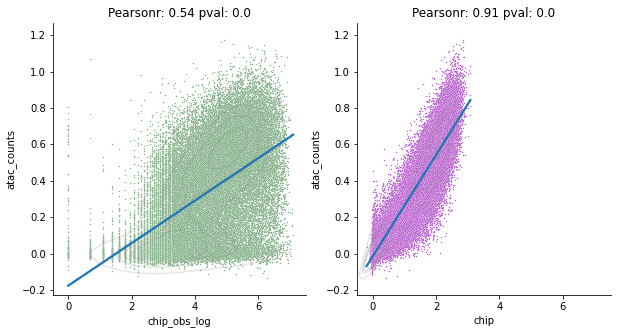

In [9]:
data["chip_obs_log"] = np.log(data["chip_counts"]+1)
import scipy.stats
import seaborn as sns

def make_plot(xkey, keyd, data, color, savef, ax):
    sns.kdeplot(
        ax=ax,
        data=data,
        x=xkey,
        y=keyd,
        levels=5,
        fill=False,
        alpha=0.2,
        color="grey",
        cut=2,

    )

    sns.scatterplot(ax=ax, data=data, x=xkey, y=keyd, s=2, color = color, rasterized=True)
    
    sns.regplot(ax=ax, x=xkey, y=keyd, data=data, scatter=False, ci=None)
    ppr = scipy.stats.pearsonr(data[keyd], data[xkey])
    print(ppr)
    print(scipy.stats.pearsonr(data[keyd], data[xkey]))
    ax.set_title("Pearsonr: " + str(np.round(ppr[0],2)) + " pval: "+str(ppr[1]))
    ax.spines[['right', 'top']].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

my_pal = {"ATAC Observed log counts": "#5FB4EF", "DNase Observed log counts": "#249AEC", "TOBIAS score": "#ABABAB",
         "ChromBPNet ATAC counts contrib": "#7EAD84", "ChromBPNet ATAC profile contrib":"#3D963D",
         "ChromBPNet DNase counts contrib": "#B95BD0", "ChromBPNet DNase profile contrib":"#9B4CAF"}


make_plot("chip_obs_log", "atac_counts", data, my_pal["ChromBPNet ATAC counts contrib"], "pearsonr_ctcf_counts.pdf", axes[0])
make_plot("chip", "atac_counts", data, "#B95BD0", "pearsonr_ctcf_counts.pdf", axes[1])

#plt.scatter(data['chip_counts'], data['atac_counts'])

In [16]:

chip_pp="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/digital_footprinting/HEPG2.bigwig"
#print(chip_plus)
bw_cp = pw.open(chip_pp)

dg_values = []
for i,r in data.iterrows():
    mid=int((r[1]+r[2])/2)
    val1 = np.sum(np.nan_to_num(bw_cp.values(r[0],mid-50,mid+50)))
    dg_values.append(val1)

In [27]:
print(scipy.stats.pearsonr(np.log(np.array(dg_values)+1), data["chip"].abs()))

(0.38260006642387306, 0.0)


In [19]:
print(scipy.stats.pearsonr(dg_values, data["chip_obs_log"]))

(0.42847662303233774, 0.0)


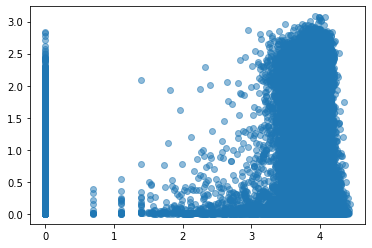

In [25]:
plt.scatter(np.log(np.array(dg_values)+1),data["chip"].abs(), alpha=0.5)